# Tumour growth paradox

In Hillen et al. (2013) (Hillen, T., Enderling, H. & Hahnfeldt, P. The Tumor Growth Paradox and Immune System-Mediated Selection for Cancer Stem Cells. Bull Math Biol 75, 161–184 (2013). https://doi.org/10.1007/s11538-012-9798-x) they introduce the tumour growth paradox. 
This is the idea that an increased death rate of non-CSCs can actually lead to a larger tumour at a later time.
Primerlily as the non-CSCs were competing with the CSCs and thus killing more non-CSCs just allows for the CSCs to dominate growth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#from matplotlib.colors import ListedColormap, BoundaryNorm

import gsc_model_functions as gmf

In [2]:
# Colors from red to green
cmap = plt.get_cmap('RdYlGn')
# Interpolated colors at these positions
col = [cmap(p) for p in np.linspace(0, 1, 11)]


def plot_all_compartments(u, t, ax, cols_= 'k', ls = '-'):
    for i in range(len(u[1,:])):
        ax.plot(t,u[:,i], color  = col[i])
    
    ax.plot(t,np.sum(u, axis=1), color = cols_, linestyle=ls)

In [3]:
# params for model simulation
dt = 0.1
t_end = 13000

dt = 0.1
t_end = 13000
n = 10 
r = np.zeros(n)
r[0] = 1
Ps = 0.52
k = 1
ms = 0.2
mv = np.ones(n)*0.4
mv[-1] = 0
delta_s = 0.001
#delta_v = np.ones(n)*0.05
delta_v_vals = np.array([0.01,0.05,0.5])


# Consider 4 different ICs
IC = 0.0001


u0 = np.zeros(n+1)
u0[0] = IC


u0_1 = np.zeros(n+1)
u0_1[0] = IC


u0_2 = np.zeros(n+1)
u0_2[0] = IC


t,u = gmf.simulate_simple(t_end,dt,u0,n,Ps,k,ms,mv,delta_s,np.ones(n)*delta_v_vals[0],r)
t,u1 = gmf.simulate_simple(t_end,dt,u0_1,n,Ps,k,ms,mv,delta_s,np.ones(n)*delta_v_vals[1],r)
t,u2 = gmf.simulate_simple(t_end,dt,u0_2,n,Ps,k,ms,mv,delta_s,np.ones(n)*delta_v_vals[2],r)

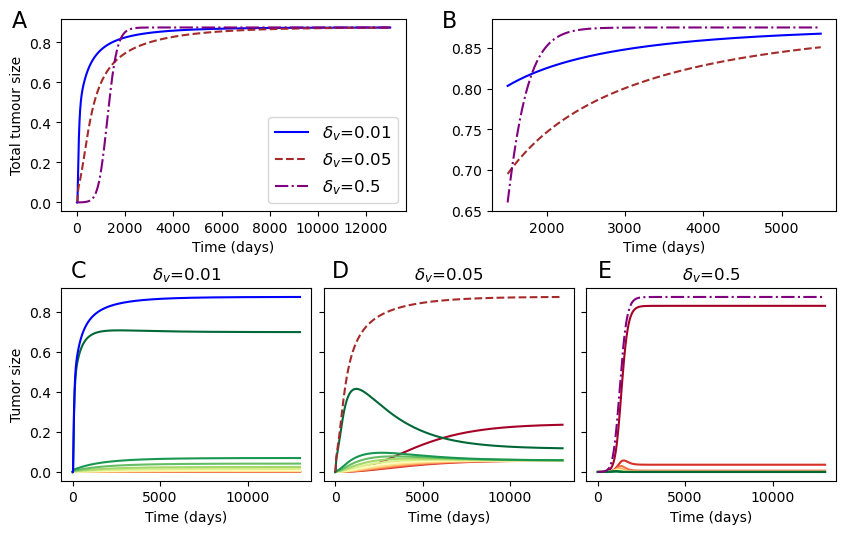

In [4]:

#from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig = plt.figure(constrained_layout=False, figsize=(10,6))

# Outer grid: 2 rows
outer = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1, 1], hspace=0.4)

# ---------- Top row: 2 equal-width plots ----------
top = outer[0].subgridspec(nrows=1, ncols=2, wspace = 0.25)

ax_t1 = fig.add_subplot(top[0, 0])
ax_t2 = fig.add_subplot(top[0, 1])


# top left plot: total tumour size comparison
ax_t1.plot(t,np.sum(u, axis=1), color = 'b', label = f'$\delta_v$={delta_v_vals[0]}')
ax_t1.plot(t,np.sum(u1, axis=1), color = 'brown', linestyle='--', label = f'$\delta_v$={delta_v_vals[1]}')
ax_t1.plot(t,np.sum(u2, axis=1), color = 'purple', linestyle='-.', label = f'$\delta_v$={delta_v_vals[2]}')
ax_t1.legend(fontsize = 12)
ax_t1.set_xlabel('Time (days)')
ax_t1.set_ylabel('Total tumour size')

# top right plot zoomed in total tumor size comparison
t2_start = 15000
t2_end = 55000
ax_t2.plot(t[t2_start:t2_end],np.sum(u[t2_start:t2_end], axis=1), color = 'b', label = f'$\delta_v$={delta_v_vals[0]}')
ax_t2.plot(t[t2_start:t2_end],np.sum(u1[t2_start:t2_end], axis=1), color = 'brown', linestyle='--', label = f'$\delta_v$={delta_v_vals[1]}')
ax_t2.plot(t[t2_start:t2_end],np.sum(u2[t2_start:t2_end], axis=1), color = 'purple', linestyle='-.', label = f'$\delta_v$={delta_v_vals[2]}')
ax_t2.set_xlabel('Time (days)')


# ---------- Bottom row: 3 equal plots + colorbar ----------
bottom = outer[1].subgridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 1],  # last column for colorbar
    wspace=0.05
)

ax_b1 = fig.add_subplot(bottom[0, 0])
ax_b2 = fig.add_subplot(bottom[0, 1])
ax_b3 = fig.add_subplot(bottom[0, 2])


plot_all_compartments(u, t,ax_b1, cols_ = 'blue', ls='-')
plot_all_compartments(u1, t, ax_b2, cols_ = 'brown', ls='--')
plot_all_compartments(u2, t,ax_b3, cols_ = 'purple', ls='-.')

# set titles
ax_b1.set_title(f'$\delta_v$={delta_v_vals[0]}')
ax_b2.set_title(f'$\delta_v$={delta_v_vals[1]}')
ax_b3.set_title(f'$\delta_v$={delta_v_vals[2]}')

# set x labels
ax_b1.set_xlabel('Time (days)')
ax_b2.set_xlabel('Time (days)')
ax_b3.set_xlabel('Time (days)')

ax_b1.set_xticks([0, 5000,10000])
ax_b2.set_xticks([0, 5000,10000])
ax_b3.set_xticks([0, 5000,10000])

# set y labels (only need for left-most plot)
ax_b1.set_ylabel('Tumor size')
ax_b2.set_ylabel('')
ax_b3.set_ylabel('')

# remove y-ticks for right two plots
ax_b2.set_yticklabels([])
ax_b3.set_yticklabels([])

# Create colorbar axis inside the right-most bottom axis
'''
cax = inset_axes(
    ax_b3,                # reference axis
    width="4%",            # relative width
    height="100%",         # EXACT same height
    loc="lower left",
    bbox_to_anchor=(1.05, 0, 1, 1),
    bbox_transform=ax_b3.transAxes,
    borderpad=0
)

cb = fig.colorbar(im, cax=cax)
cb.set_label("Intensity", fontsize=12)
'''

# increase tick label size
for ax in [ax_t1, ax_t2, ax_b1, ax_b2, ax_b3]:
    ax.tick_params(labelsize=10)

# add ABC labels
ax_t1.text(-0.1, 1.05, 'A', transform=ax_t1.transAxes,fontsize=16, va='top', ha='right')
ax_t2.text(-0.1, 1.05, 'B', transform=ax_t2.transAxes,fontsize=16, va='top', ha='right')

ax_b1.text(0.1, 1.15, 'C', transform=ax_b1.transAxes,fontsize=16, va='top', ha='right')
ax_b2.text(0.1, 1.15, 'D', transform=ax_b2.transAxes,fontsize=16, va='top', ha='right')
ax_b3.text(0.1, 1.15, 'E', transform=ax_b3.transAxes,fontsize=16, va='top', ha='right')

#plt.savefig("Figs/GSC_initiate.svg", bbox_inches="tight")
plt.savefig("Figs/tumour_growth_paradox.pdf", bbox_inches="tight")
plt.show()